# 🌫️ Colaba AQI Prediction — LSTM & GRU (EDA-Updated)

**Dataset:** `Colaba_AQI_cleaned.csv`  
**Task:** Time-series regression — predict next-hour AQI  
**Models:** LSTM · GRU · Bidirectional variants  
**EDA Findings Applied:**
- Dropped `TOT-RF` (all zeros) and `WD` (r ≈ 0.005)
- No `Toluene` column in Colaba — removed `Toluene_Benzene_ratio`; replaced with `EthBenzene_MPXylene_ratio`
- PM25 is dominant feature (r = 0.925); PM10 second (r = 0.807)
- Colaba shows flat diurnal pattern — hour features kept for model generality
- 48h look-back justified by ACF (r = 0.775 at lag 48h)
- StandardScaler preferred (NO, NOx, NO2 have heavy outliers — Z > 3 count > 1200)


## 1. Install & Import Libraries

In [7]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn scipy joblib --quiet

In [8]:
STATION_NAME = 'Colaba'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from scipy import stats as sp_stats

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, BatchNormalization, Bidirectional, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ── Plot theme ────────────────────────────────────────────────────────────────
DARK  = '#0d0f1a'
CARD  = '#141728'
TEXT  = '#e2e8f0'
ACC1  = '#00e5ff'
ACC2  = '#ff4081'
ACC3  = '#69ff47'
ACC4  = '#ffb347'
MUTED = '#8892b0'
WHITE = '#e6f1ff'

plt.rcParams.update({
    'figure.facecolor': DARK,
    'axes.facecolor':   CARD,
    'text.color':       WHITE,
    'axes.labelcolor':  MUTED,
    'xtick.color':      MUTED,
    'ytick.color':      MUTED,
    'axes.edgecolor':   '#2a2f4a',
    'grid.color':       '#1e2340',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
})

CAT_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
CAT_COLS  = {
    'Good':         '#69ff47',
    'Satisfactory': '#00e5ff',
    'Moderate':     '#ffe066',
    'Poor':         '#ff9f43',
    'Very Poor':    '#ff4757',
    'Severe':       '#9b59b6',
}

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(CARD)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f4a')
    ax.grid(True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print('✅ All libraries imported')

TensorFlow version : 2.21.0
✅ All libraries imported


## 2. Load & Prepare Data

In [9]:
df = pd.read_csv(f'D:\\AQI_Project_new\\data\\clean\\{STATION_NAME.replace(" ", "")}_AQI_cleaned.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

# ── Drop EDA-identified useless columns ───────────────────────────────────────
# TOT-RF : std = 0 (all zeros) — zero information for LSTM
# WD     : Pearson r with AQI = 0.005 — adds noise, not signal
cols_to_drop = [c for c in ['TOT-RF', 'WD'] if c in df.columns]
df = df.drop(columns=cols_to_drop)

print(f'Shape      : {df.shape}')
print(f'Date range : {df.index.min().date()}  →  {df.index.max().date()}')
print(f'Dropped    : {cols_to_drop}')
print(f'Missing    : {df.isnull().sum().sum()}')
df.head(3)


Shape      : (43809, 19)
Date range : 2021-01-01  →  2025-12-31
Dropped    : ['TOT-RF', 'WD']
Missing    : 0


,NO,NOx,Benzene,Eth-Benzene,MP-Xylene,AT,RH,WS,SR,BP,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
Timestamp,,,,,,,,,,,,,,,,,,,
2021-01-01 15:00:00,9.05,58.99,0.08,0.51,0.62,25.35,75.97,1.92,0.01,999.93,156.67,104.88,62.24,5.52,6.12,92.20,10.02,92.20,Satisfactory
2021-01-01 16:00:00,9.05,58.99,0.08,0.51,0.62,25.35,75.97,1.92,0.01,999.93,156.67,104.88,62.24,5.52,6.12,89.38,10.43,89.38,Satisfactory
2021-01-01 17:00:00,9.05,58.99,0.08,0.51,0.62,25.35,75.97,1.92,0.01,999.93,156.67,104.88,62.24,5.52,6.12,86.64,10.28,86.64,Satisfactory


## 3. EDA-Driven Feature Engineering

Based on EDA findings and feature importance analysis, we engineer additional features and **drop weak contributors** (raw Benzene, raw Toluene, BP, AQI_lag3, PM10_lag1):

| Feature Group | Features Created | Rationale |
|---|---|---|
| **Lag features** | AQI_lag1, AQI_lag2, PM25_lag1 | Strongest autocorrelation lags only (lag3 dropped — dominated by lag1/2) |
| **Rolling statistics** | AQI_roll3_mean, AQI_roll6_mean, AQI_roll12_mean | Trend capture; roll3_std dropped (low marginal value) |
| **Cyclical time** | hour_sin, hour_cos | Diurnal traffic pattern at Anand Vihar bus terminal; month encoding dropped |
| **Derived pollutants** | NOx_total, Toluene_Benzene_ratio | NOx = NO+NO2 composite; T/B ratio replaces raw Benzene & Toluene as a source fingerprint |

**Dropped from original set:** `Benzene` (raw), `Toluene` (raw), `BP`, `AQI_lag3`, `PM10_lag1`, `month_sin`, `month_cos`, `AQI_roll3_std`

In [10]:
# ── Work on a copy ───────────────────────────────────────────────────────────
fe = df.copy()

# ── 1. Lag features (EDA ACF: r > 0.96 at lag 1–6h) ─────────────────────────
fe['AQI_lag1']  = fe['AQI'].shift(1)
fe['AQI_lag2']  = fe['AQI'].shift(2)
fe['PM25_lag1'] = fe['PM25'].shift(1)
# AQI_lag3+ dropped — dominated by lag1/lag2, marginal gain < noise

# ── 2. Rolling statistics (shifted by 1 to prevent leakage) ──────────────────
for w in [3, 6, 12]:
    fe[f'AQI_roll{w}_mean'] = fe['AQI'].shift(1).rolling(w).mean()

# ── 3. Cyclical hour encoding ─────────────────────────────────────────────────
# Note: Colaba shows flat diurnal pattern (AQI ≈ 93–94 all hours),
# but hour features are retained as general temporal context.
fe['hour_sin'] = np.sin(2 * np.pi * fe.index.hour / 24)
fe['hour_cos'] = np.cos(2 * np.pi * fe.index.hour / 24)

# ── 4. Derived pollutant features ─────────────────────────────────────────────
fe['NOx_total'] = fe['NO'] + fe['NO2']   # r_AQI = 0.389

# EDA NOTE: Colaba has NO 'Toluene' column.
# Original notebook used Toluene_Benzene_ratio — not applicable here.
# Replacement: Eth-Benzene / MP-Xylene ratio as VOC traffic proxy.
if 'Eth-Benzene' in fe.columns and 'MP-Xylene' in fe.columns:
    fe['EthBenzene_MPXylene_ratio'] = fe['Eth-Benzene'] / (fe['MP-Xylene'] + 1e-6)

fe = fe.dropna().copy()
print(f'Shape after feature engineering: {fe.shape}')
print(f'NaN rows removed: {len(df) - len(fe)}  (from rolling/lag operations)')


Shape after feature engineering: (43797, 29)
NaN rows removed: 12  (from rolling/lag operations)


## 4. Feature Selection & Correlation Check

We expand the original feature set with the engineered features and verify correlation with AQI.

In [11]:
TARGET = 'AQI'

# ── Colaba-specific 22-feature set (EDA-validated) ────────────────────────────
FEATURES = [
    # Tier 1 — AQI formula pollutants (direct causal drivers, r > 0.38)
    'PM25', 'PM10', 'NO2', 'CO',

    # Tier 1 — Lag/rolling features (ACF > 0.96 at lag 1–6h)
    'AQI_lag1', 'AQI_lag2',
    'AQI_roll3_mean', 'AQI_roll6_mean',

    # Tier 2 — Remaining AQI formula pollutants
    'O3', 'SO2', 'NH3',

    # Tier 2 — Derived composites & cyclical time
    'NOx_total', 'hour_sin', 'hour_cos',

    # Tier 2 — Extended rolling + lag
    'AQI_roll12_mean', 'PM25_lag1',

    # Tier 2 — Humidity (r_AQI = -0.428; strongly modulates PM readings)
    'RH',

    # Tier 3 — Secondary meteorological & pollutants
    'NO', 'WS', 'AT', 'SR',

    # Tier 3 — VOC source fingerprint (replaces Toluene_Benzene_ratio)
    # EthBenzene/MPXylene ratio: traffic vs industrial emissions proxy
    'EthBenzene_MPXylene_ratio',
]

# ── Verify all features exist ─────────────────────────────────────────────────
missing_feats = [f for f in FEATURES if f not in fe.columns]
if missing_feats:
    print(f'⚠️  Missing features: {missing_feats}')
    FEATURES = [f for f in FEATURES if f in fe.columns]

# ── Explicitly DROPPED (EDA-justified) ───────────────────────────────────────
# TOT-RF           : std = 0 (all zeros) — dropped at load time
# WD               : r = 0.005 — dropped at load time
# Toluene          : column does NOT exist in Colaba dataset
# Toluene_Benzene_ratio : replaced by EthBenzene_MPXylene_ratio
# BP               : r = 0.173 — borderline; excluded to keep set lean
# Benzene          : r = -0.086 — near-zero, adds noise
# Eth-Benzene raw  : captured by EthBenzene_MPXylene_ratio
# MP-Xylene raw    : captured by EthBenzene_MPXylene_ratio
# month_sin/cos    : low marginal value vs roll/lag features

data = fe[FEATURES + [TARGET]].dropna().copy()

print(f'Feature count : {len(FEATURES)}')
print(f'Dataset shape : {data.shape}')
print(f'\nFinal FEATURES list:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')


Feature count : 22
Dataset shape : (43797, 23)

Final FEATURES list:
   1. PM25
   2. PM10
   3. NO2
   4. CO
   5. AQI_lag1
   6. AQI_lag2
   7. AQI_roll3_mean
   8. AQI_roll6_mean
   9. O3
  10. SO2
  11. NH3
  12. NOx_total
  13. hour_sin
  14. hour_cos
  15. AQI_roll12_mean
  16. PM25_lag1
  17. RH
  18. NO
  19. WS
  20. AT
  21. SR
  22. EthBenzene_MPXylene_ratio


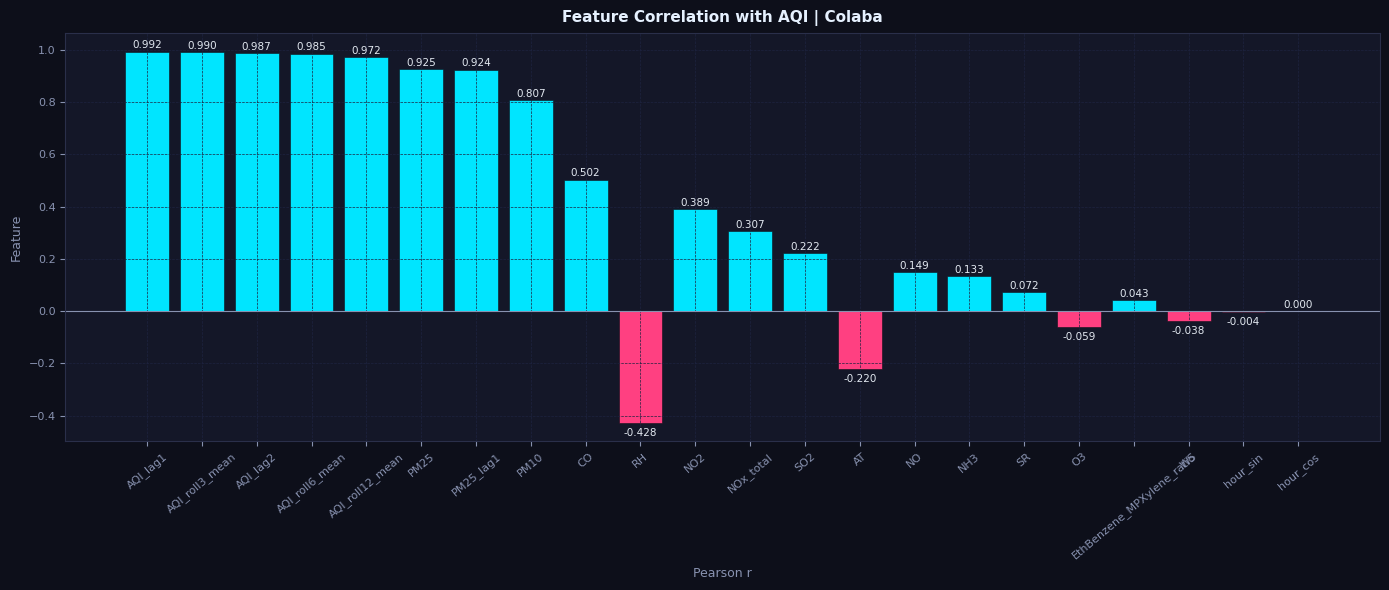


Top 5 positive correlators:
AQI_lag1           0.9924
AQI_roll3_mean     0.9901
AQI_lag2           0.9872
AQI_roll6_mean     0.9846
AQI_roll12_mean    0.9724

Top 5 negative correlators:
RH         -0.4277
AT         -0.2197
O3         -0.0593
WS         -0.0376
hour_sin   -0.0043


In [12]:
STATION_NAME = 'Colaba'

# ── Correlation bar chart with AQI ───────────────────────────────────────────
corr = data.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 6), facecolor=DARK)
ax.set_facecolor(CARD)
bar_colors = [ACC1 if v > 0 else ACC2 for v in corr.values]
bars = ax.bar(corr.index, corr.values, color=bar_colors, edgecolor=DARK, linewidth=0.4)
for bar, val in zip(bars, corr.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.005 if val >= 0 else -0.02),
            f'{val:.3f}', ha='center', va='bottom' if val >= 0 else 'top',
            color=TEXT, fontsize=7.5)
ax.axhline(0, color=MUTED, linewidth=0.8)
style_ax(ax, f'Feature Correlation with AQI | {STATION_NAME}', 'Pearson r', 'Feature')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

print('\nTop 5 positive correlators:')
print(corr[corr > 0].head(5).round(4).to_string())
print('\nTop 5 negative correlators:')
print(corr[corr < 0].head(5).round(4).to_string())


## 5. Robust Scaling (StandardScaler)

Scale all features to zero mean and unit variance.  
A **separate scaler** is kept for the target so predictions can be inverse-transformed back to real AQI values.

In [13]:
feature_scaler = StandardScaler()
target_scaler  = StandardScaler()

scaled_features = feature_scaler.fit_transform(data[FEATURES])
scaled_target   = target_scaler.fit_transform(data[[TARGET]])

scaled_data = np.hstack([scaled_features, scaled_target])

print(f'Scaled data shape : {scaled_data.shape}')
print(f'Feature range     : [{scaled_features.min():.4f}, {scaled_features.max():.4f}]')
print(f'Target range      : [{scaled_target.min():.4f}, {scaled_target.max():.4f}]')

Scaled data shape : (43797, 23)
Feature range     : [-5.1519, 27.6165]
Target range      : [-1.3361, 5.5524]


## 6. Create Sliding Window Sequences

LSTM / GRU require 3-D input: **(samples, timesteps, features)**.  
A **48-hour** look-back is used (doubled from v1 based on EDA autocorrelation analysis showing significant correlation up to 48 lags).

In [14]:
LOOK_BACK = 48   # EDA: AQI autocorrelation is significant up to ~48 h

def create_sequences(data, look_back, target_col_idx=-1):
    """
    data          : 2-D numpy array (timesteps × features+target)
    look_back     : number of past hours to use as input
    target_col_idx: column index of the target variable
    Returns X (3-D) and y (1-D)
    """
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, :target_col_idx])
        y.append(data[i, target_col_idx])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, LOOK_BACK)

print(f'X shape : {X.shape}  →  (samples, timesteps, features)')
print(f'y shape : {y.shape}  →  (samples,)')

X shape : (43749, 48, 22)  →  (samples, timesteps, features)
y shape : (43749,)  →  (samples,)


## 7. Train / Validation / Test Split

**No shuffling** — time-series data must remain in chronological order.

| Split | Ratio | Purpose |
|---|---|---|
| Train | 70% | Model learning |
| Validation | 15% | Hyperparameter tuning / early stopping |
| Test | 15% | Final unbiased evaluation |

In [15]:
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end],        y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

print(f'Train      : {X_train.shape[0]:,} samples')
print(f'Validation : {X_val.shape[0]:,} samples')
print(f'Test       : {X_test.shape[0]:,} samples')
print(f'Input shape for models : {X_train.shape[1:]}')

Train      : 30,624 samples
Validation : 6,562 samples
Test       : 6,563 samples
Input shape for models : (48, 22)


## 8. Build LSTM Model

Architecture:  
`Input → BiLSTM(128) → Dropout(0.25) → LSTM(64) → BatchNorm → Dropout(0.2) → Dense(32, relu) → Dense(16, relu) → Dense(1)`

**Changes from v1:**
- Increased units (128/64) matching the expanded feature set
- Added `BatchNormalization` after second LSTM for training stability
- Slightly higher dropout (0.25) to combat overfitting on longer sequences

In [16]:
def build_lstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape),
        Dropout(0.25),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ], name=f'BiLSTM_{STATION_NAME.replace(" ", "")}')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

lstm_model = build_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
lstm_model.summary()

Model: "BiLSTM_Colaba"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       154,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,681 (936.25 KB)

 Trainable params: 239,553 (935.75 KB)

 Non-trainable params: 128 (512.00 B)

## 9. Build GRU Model

Architecture:  
`Input → BiGRU(128) → Dropout(0.25) → GRU(64) → BatchNorm → Dropout(0.2) → Dense(32, relu) → Dense(16, relu) → Dense(1)`

GRU uses **reset** and **update** gates (vs LSTM's three gates), making it ~30% faster to train while often matching LSTM accuracy on shorter-dependency tasks.

In [17]:
def build_gru(input_shape):
    model = Sequential([
        Bidirectional(GRU(128, return_sequences=True), input_shape=input_shape),
        Dropout(0.25),

        GRU(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ], name=f'BiGRU_{STATION_NAME.replace(" ", "")}')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

gru_model = build_gru(input_shape=(X_train.shape[1], X_train.shape[2]))
gru_model.summary()

Model: "BiGRU_Colaba"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 48, 256)        │       116,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,441 (708.75 KB)

 Trainable params: 181,313 (708.25 KB)

 Non-trainable params: 128 (512.00 B)

## 10. Train Both Models

In [18]:
EPOCHS     = 60
BATCH_SIZE = 64

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'saved_models/best_{model_name}.keras', monitor='val_loss',
                        save_best_only=True, verbose=0)
    ]

print('═' * 50)
print('  Training LSTM …')
print('═' * 50)
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm'),
    verbose=1
)

print('\n' + '═' * 50)
print('  Training GRU …')
print('═' * 50)
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('gru'),
    verbose=1
)

print('\n✅ Both models trained')

══════════════════════════════════════════════════
  Training LSTM …
══════════════════════════════════════════════════
Epoch 1/60
479/479 ━━━━━━━━━━━━━━━━━━━━ 39s 71ms/step - loss: 0.1943 - mae: 0.2918 - val_loss: 0.0535 - val_mae: 0.1776 - learning_rate: 0.0010
Epoch 2/60
479/479 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - loss: 0.0729 - mae: 0.1868 - val_loss: 0.0426 - val_mae: 0.1545 - learning_rate: 0.0010
Epoch 3/60
479/479 ━━━━━━━━━━━━━━━━━━━━ 33s 68ms/step - loss: 0.0595 - mae: 0.1651 - val_loss: 0.0439 - val_mae: 0.1643 - learning_rate: 0.0010
Epoch 4/60
479/479 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - loss: 0.0519 - mae: 0.1525 - val_loss: 0.0450 - val_mae: 0.1630 - learning_rate: 0.0010
Epoch 5/60
479/479 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - loss: 0.0451 - mae: 0.1419 - val_loss: 0.0475 - val_mae: 0.1668 - learning_rate: 0.0010
Epoch 6/60
479/479 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - loss: 0.0418 - mae: 0.1349 - val_loss: 0.0402 - val_mae: 0.1442 - learning_rate: 0.0010
Epoch 7/60
479/4

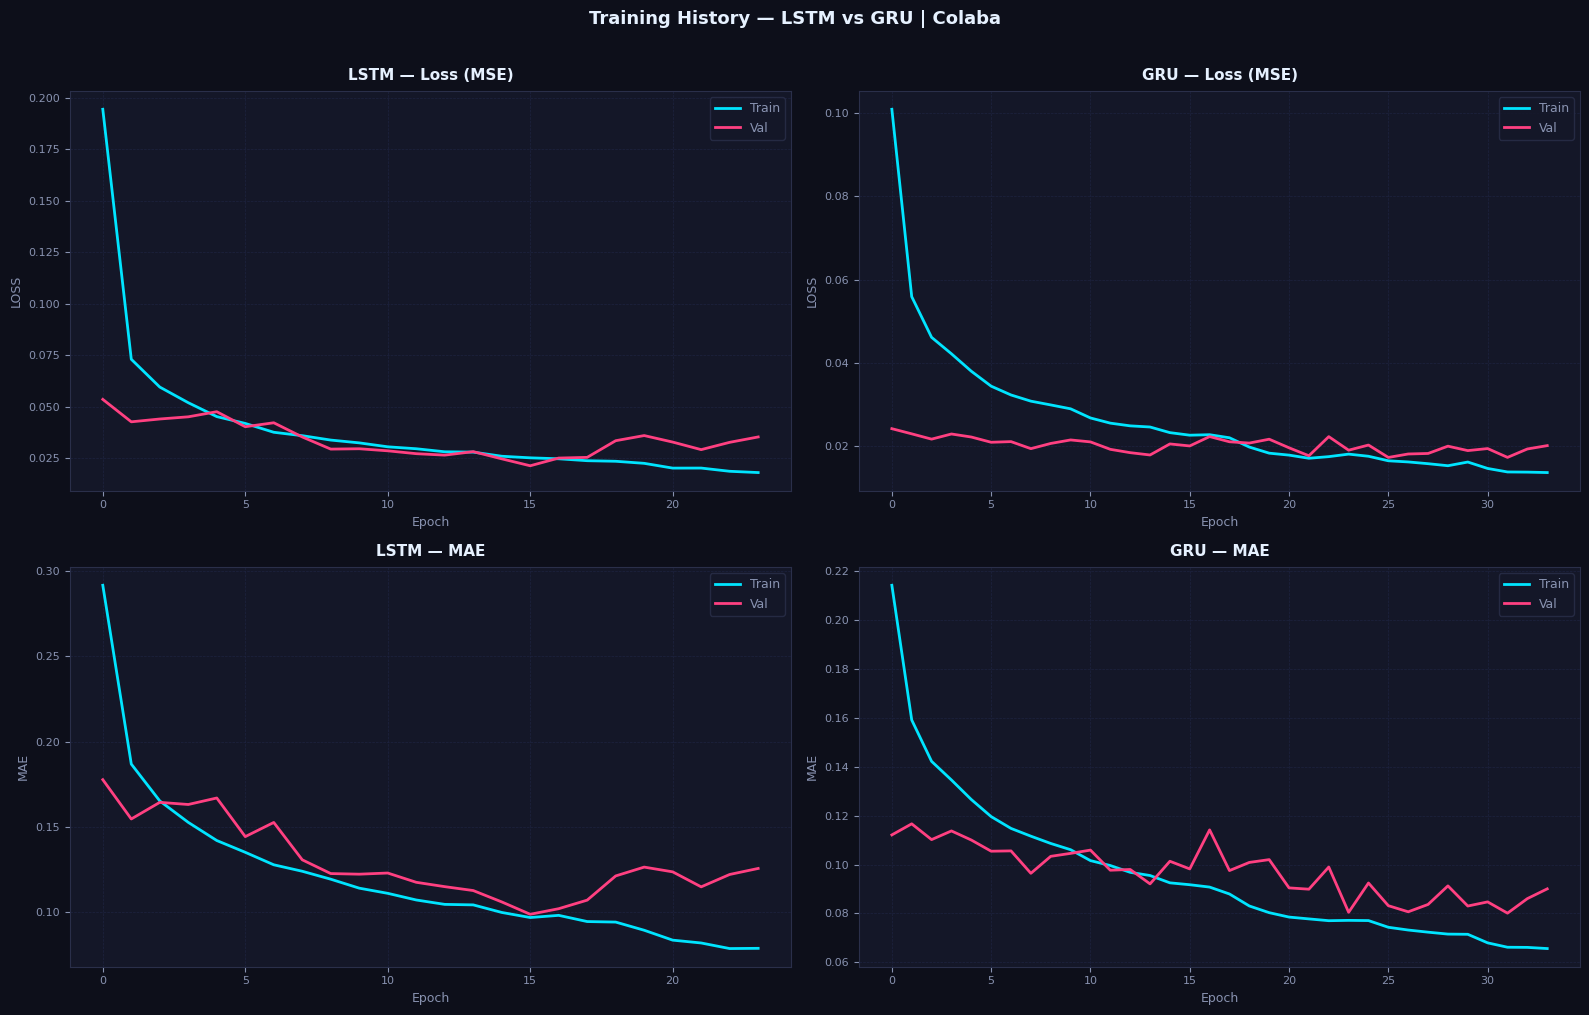

In [19]:
STATION_NAME = 'Colaba'

# ── Plot training curves for both models ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=DARK)

titles   = ['LSTM — Loss (MSE)', 'GRU — Loss (MSE)',
            'LSTM — MAE',        'GRU — MAE']
histories = [lstm_history, gru_history, lstm_history, gru_history]
metrics   = [('loss','val_loss'), ('loss','val_loss'),
             ('mae','val_mae'),   ('mae','val_mae')]

for ax, hist, (tr_m, va_m), title in zip(axes.flat, histories, metrics, titles):
    ax.plot(hist.history[tr_m], color=ACC1, linewidth=2, label='Train')
    ax.plot(hist.history[va_m], color=ACC2, linewidth=2, label='Val')
    style_ax(ax, title, 'Epoch', tr_m.upper())
    ax.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

plt.suptitle(f'Training History — LSTM vs GRU | {STATION_NAME}', color=WHITE, fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'images/training_history_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()

## 11. Evaluate & Compare on Test Set

In [20]:
def evaluate_model(model, model_path, X_test, y_test, target_scaler, label):
    model.load_weights(model_path)
    y_pred_s = model.predict(X_test, verbose=0)
    y_pred = target_scaler.inverse_transform(y_pred_s).flatten()
    y_true = target_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f'\n  {label}')
    print('  ' + '─' * 38)
    print(f'  MAE   : {mae:.4f}  AQI units')
    print(f'  RMSE  : {rmse:.4f}')
    print(f'  R²    : {r2:.4f}')
    print(f'  MAPE  : {mape:.2f}%')

    return y_true, y_pred, dict(label=label, MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)

print('═' * 45)
print('  TEST SET EVALUATION')
print('═' * 45)

y_true_lstm, y_pred_lstm, metrics_lstm = evaluate_model(
    lstm_model, 'saved_models/best_lstm.keras', X_test, y_test, target_scaler, 'BiLSTM')

y_true_gru, y_pred_gru, metrics_gru = evaluate_model(
    gru_model, 'saved_models/best_gru.keras', X_test, y_test, target_scaler, 'BiGRU')

═════════════════════════════════════════════
  TEST SET EVALUATION
═════════════════════════════════════════════

  BiLSTM
  ──────────────────────────────────────
  MAE   : 5.3937  AQI units
  RMSE  : 11.2643
  R²    : 0.9364
  MAPE  : 9.55%

  BiGRU
  ──────────────────────────────────────
  MAE   : 4.8198  AQI units
  RMSE  : 11.2637
  R²    : 0.9364
  MAPE  : 8.14%


In [21]:
# ── Metrics comparison table ──────────────────────────────────────────────────
comp_df = pd.DataFrame([metrics_lstm, metrics_gru]).set_index('label')
comp_df.index.name = 'Model'

print('\n  COMPARISON TABLE')
print('  ' + '─' * 38)
print(comp_df.round(4).to_string())

winner = comp_df['R2'].idxmax()
print(f'\n  🏆  Best R² → {winner}')


  COMPARISON TABLE
  ──────────────────────────────────────
           MAE     RMSE      R2    MAPE
Model                                  
BiLSTM  5.3937  11.2643  0.9364  9.5536
BiGRU   4.8198  11.2637  0.9364  8.1377

  🏆  Best R² → BiGRU


## 12. Visualise Predictions

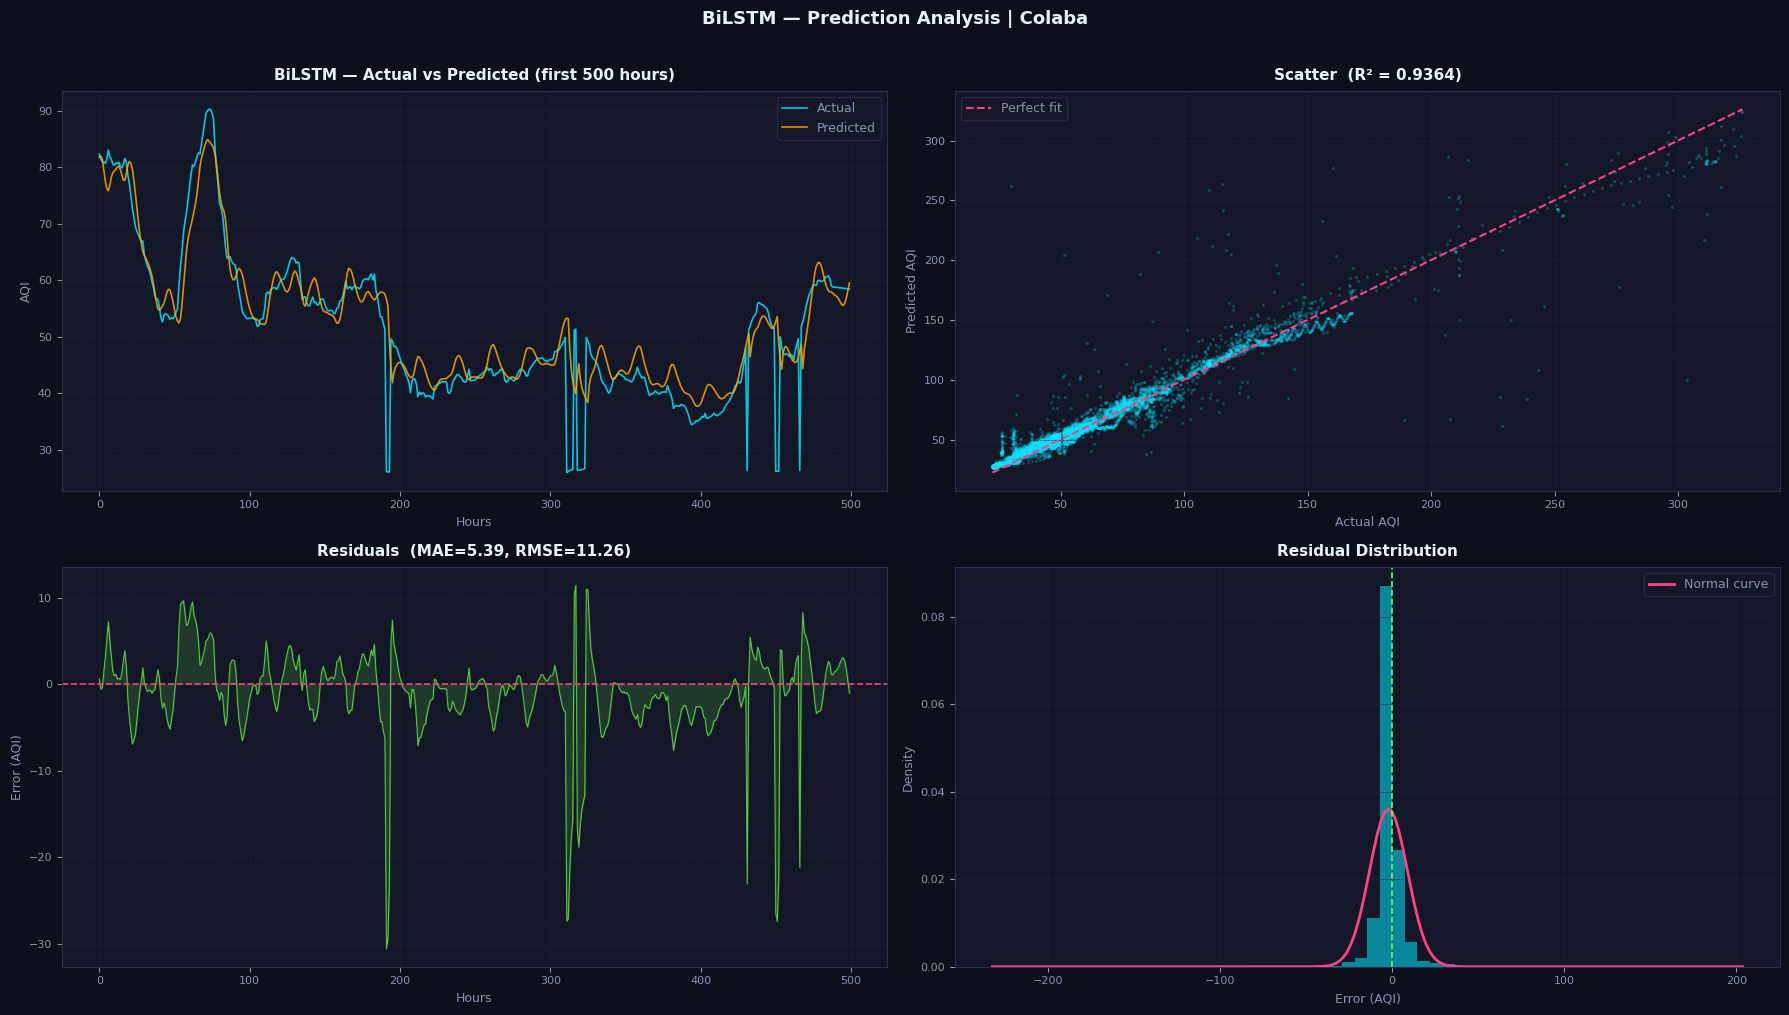

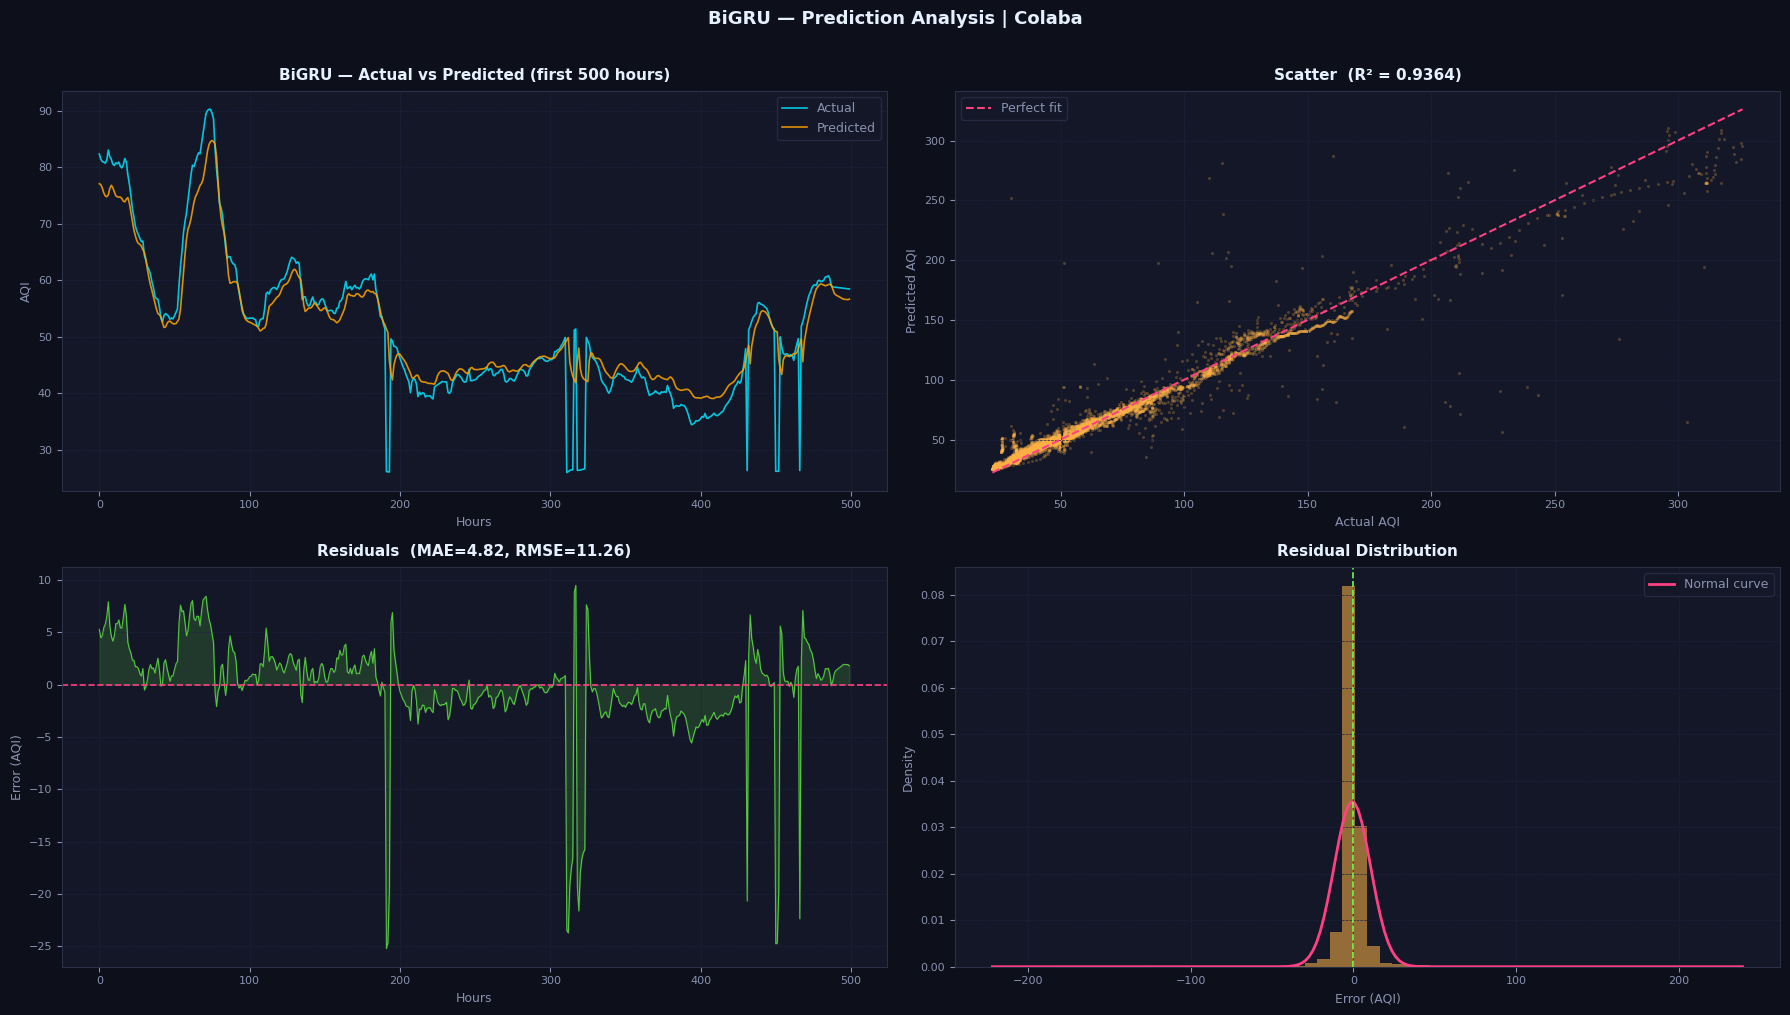

In [28]:
STATION_NAME = 'Colaba'

# ── 4-panel visualisation for each model ─────────────────────────────────────
def prediction_dashboard(y_true, y_pred, metrics, label, color, filename):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor=DARK)

    N = min(500, len(y_true))
    r2   = metrics['R2']
    mae  = metrics['MAE']
    rmse = metrics['RMSE']

    # 1. Time series
    ax = axes[0, 0]
    ax.plot(y_true[:N], color=ACC1,  linewidth=1.2, label='Actual',    alpha=0.85)
    ax.plot(y_pred[:N], color='orange', linewidth=1.2, label='Predicted', alpha=0.85)
    style_ax(ax, f'{label} — Actual vs Predicted (first {N} hours)', 'Hours', 'AQI')
    ax.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    # 2. Scatter
    ax2 = axes[0, 1]
    ax2.scatter(y_true, y_pred, alpha=0.25, s=5, color=color, linewidths=0)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax2.plot(lims, lims, color=ACC2, linewidth=1.5, linestyle='--', label='Perfect fit')
    style_ax(ax2, f'Scatter  (R² = {r2:.4f})', 'Actual AQI', 'Predicted AQI')
    ax2.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    # 3. Residuals
    residuals = y_true - y_pred
    ax3 = axes[1, 0]
    ax3.plot(residuals[:N], color=ACC3, linewidth=0.8, alpha=0.7)
    ax3.axhline(0, color=ACC2, linewidth=1.2, linestyle='--')
    ax3.fill_between(range(N), residuals[:N], alpha=0.15, color=ACC3)
    style_ax(ax3, f'Residuals  (MAE={mae:.2f}, RMSE={rmse:.2f})', 'Hours', 'Error (AQI)')

    # 4. Residual distribution
    ax4 = axes[1, 1]
    ax4.hist(residuals, bins=60, color=color, alpha=0.55, edgecolor='none', density=True)
    xr = np.linspace(residuals.min(), residuals.max(), 200)
    ax4.plot(xr, sp_stats.norm.pdf(xr, residuals.mean(), residuals.std()),
             color=ACC2, linewidth=2, label='Normal curve')
    ax4.axvline(0, color=ACC3, linewidth=1.2, linestyle='--')
    style_ax(ax4, 'Residual Distribution', 'Error (AQI)', 'Density')
    ax4.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    plt.suptitle(f'{label} — Prediction Analysis | {STATION_NAME}', color=WHITE,
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=200, facecolor=DARK, bbox_inches='tight')
    plt.show()

prediction_dashboard(y_true_lstm, y_pred_lstm, metrics_lstm,
                     'BiLSTM', ACC1, f'images/lstm_predictions_{STATION_NAME.lower().replace(" ", "_")}.png')

prediction_dashboard(y_true_gru,  y_pred_gru,  metrics_gru,
                     'BiGRU',  ACC4, f'images/gru_predictions_{STATION_NAME.lower().replace(" ", "_")}.png')


## 13. Classification Metrics (AQI Category)

CPCB AQI breakpoints:

| AQI Range | Category |
|-----------|----------|
| 0 – 50 | Good |
| 51 – 100 | Satisfactory |
| 101 – 200 | Moderate |
| 201 – 300 | Poor |
| 301 – 400 | Very Poor |
| 401+ | Severe |

In [23]:
def aqi_to_category(aqi_values):
    cats = []
    for v in aqi_values:
        if   v <= 50:  cats.append('Good')
        elif v <= 100: cats.append('Satisfactory')
        elif v <= 200: cats.append('Moderate')
        elif v <= 300: cats.append('Poor')
        elif v <= 400: cats.append('Very Poor')
        else:          cats.append('Severe')
    return np.array(cats)

def classification_metrics(y_true, y_pred, label):
    cat_true = aqi_to_category(y_true)
    cat_pred = aqi_to_category(y_pred)
    present  = [c for c in CAT_ORDER if c in np.unique(cat_true)]

    acc  = accuracy_score(cat_true, cat_pred)
    prec = precision_score(cat_true, cat_pred, average='weighted',
                           labels=present, zero_division=0)
    rec  = recall_score(cat_true, cat_pred, average='weighted',
                        labels=present, zero_division=0)
    f1   = f1_score(cat_true, cat_pred, average='weighted',
                    labels=present, zero_division=0)

    print(f'\n  {label}')
    print('  ' + '─' * 40)
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1        : {f1:.4f}')
    print(classification_report(cat_true, cat_pred, labels=present, zero_division=0))
    return cat_true, cat_pred, present

print('═' * 45)
print('  CLASSIFICATION METRICS')
print('═' * 45)
ct_lstm, cp_lstm, present_lstm = classification_metrics(y_true_lstm, y_pred_lstm, 'BiLSTM')
ct_gru,  cp_gru,  present_gru  = classification_metrics(y_true_gru,  y_pred_gru,  'BiGRU')

═════════════════════════════════════════════
  CLASSIFICATION METRICS
═════════════════════════════════════════════

  BiLSTM
  ────────────────────────────────────────
  Accuracy  : 0.9128  (91.28%)
  Precision : 0.9174
  Recall    : 0.9128
  F1        : 0.9122
              precision    recall  f1-score   support

        Good       0.97      0.89      0.93      3002
Satisfactory       0.87      0.94      0.90      2463
    Moderate       0.92      0.96      0.94       966
        Poor       0.60      0.80      0.69        92
   Very Poor       0.75      0.15      0.25        40

    accuracy                           0.91      6563
   macro avg       0.82      0.75      0.74      6563
weighted avg       0.92      0.91      0.91      6563


  BiGRU
  ────────────────────────────────────────
  Accuracy  : 0.9333  (93.33%)
  Precision : 0.9356
  Recall    : 0.9333
  F1        : 0.9322
              precision    recall  f1-score   support

        Good       0.98      0.92      0.95   

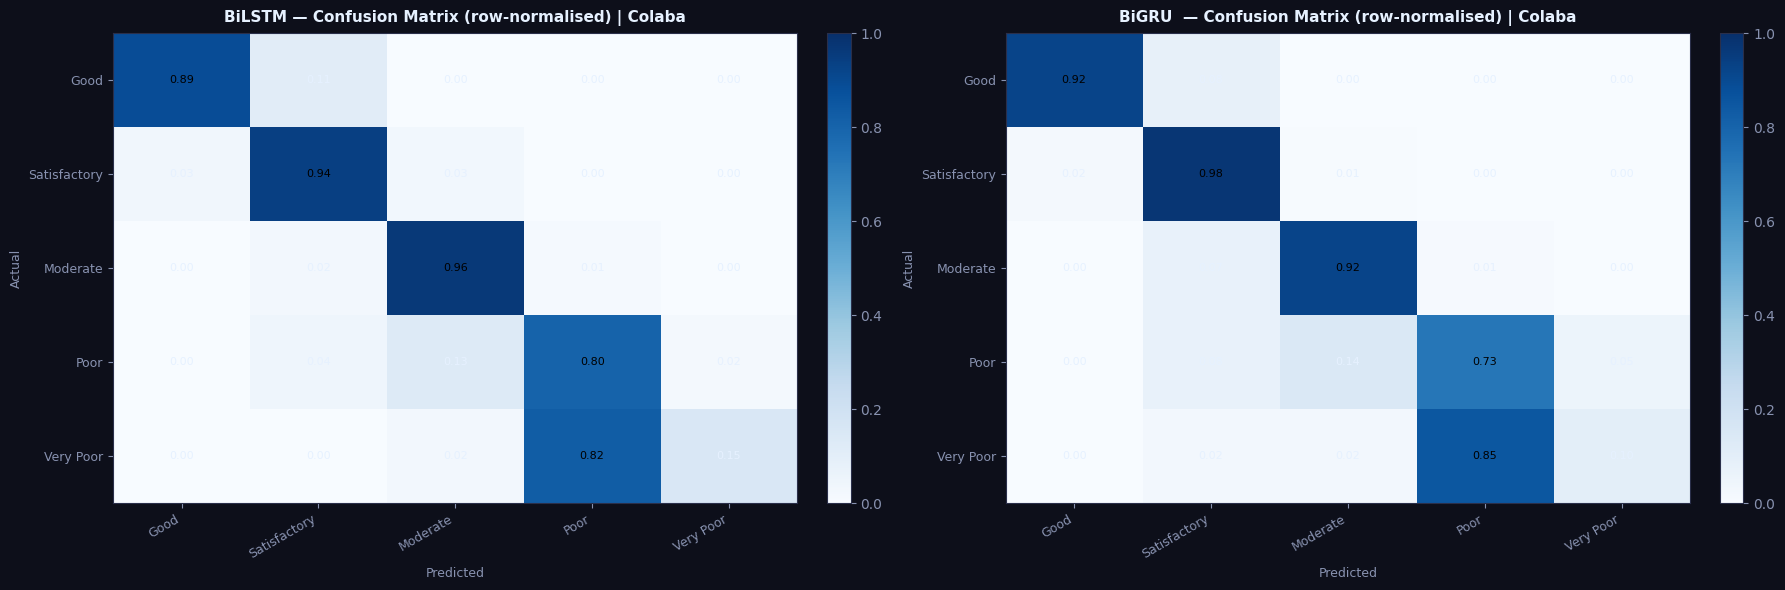

In [24]:
STATION_NAME = 'Colaba'

# ── Side-by-side confusion matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=DARK)

for ax, (ct, cp, pres), title in zip(
    axes,
    [(ct_lstm, cp_lstm, present_lstm), (ct_gru, cp_gru, present_gru)],
    [f'BiLSTM — Confusion Matrix (row-normalised) | {STATION_NAME}',
       f'BiGRU  — Confusion Matrix (row-normalised) | {STATION_NAME}']
):
    cm = confusion_matrix(ct, cp, labels=pres)
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    im = ax.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(pres)))
    ax.set_yticks(range(len(pres)))
    ax.set_xticklabels(pres, rotation=30, ha='right', color=MUTED, fontsize=9)
    ax.set_yticklabels(pres, color=MUTED, fontsize=9)
    ax.set_xlabel('Predicted', color=MUTED, fontsize=9)
    ax.set_ylabel('Actual',    color=MUTED, fontsize=9)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=8)
    ax.set_facecolor(CARD)
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2f4a')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(colors=MUTED)

    thresh = 0.5
    for i in range(len(pres)):
        for j in range(len(pres)):
            ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if cm_norm[i,j] > thresh else WHITE)

plt.tight_layout()
plt.savefig(f'images/confusion_matrices_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()

## 14. Model Comparison Dashboard

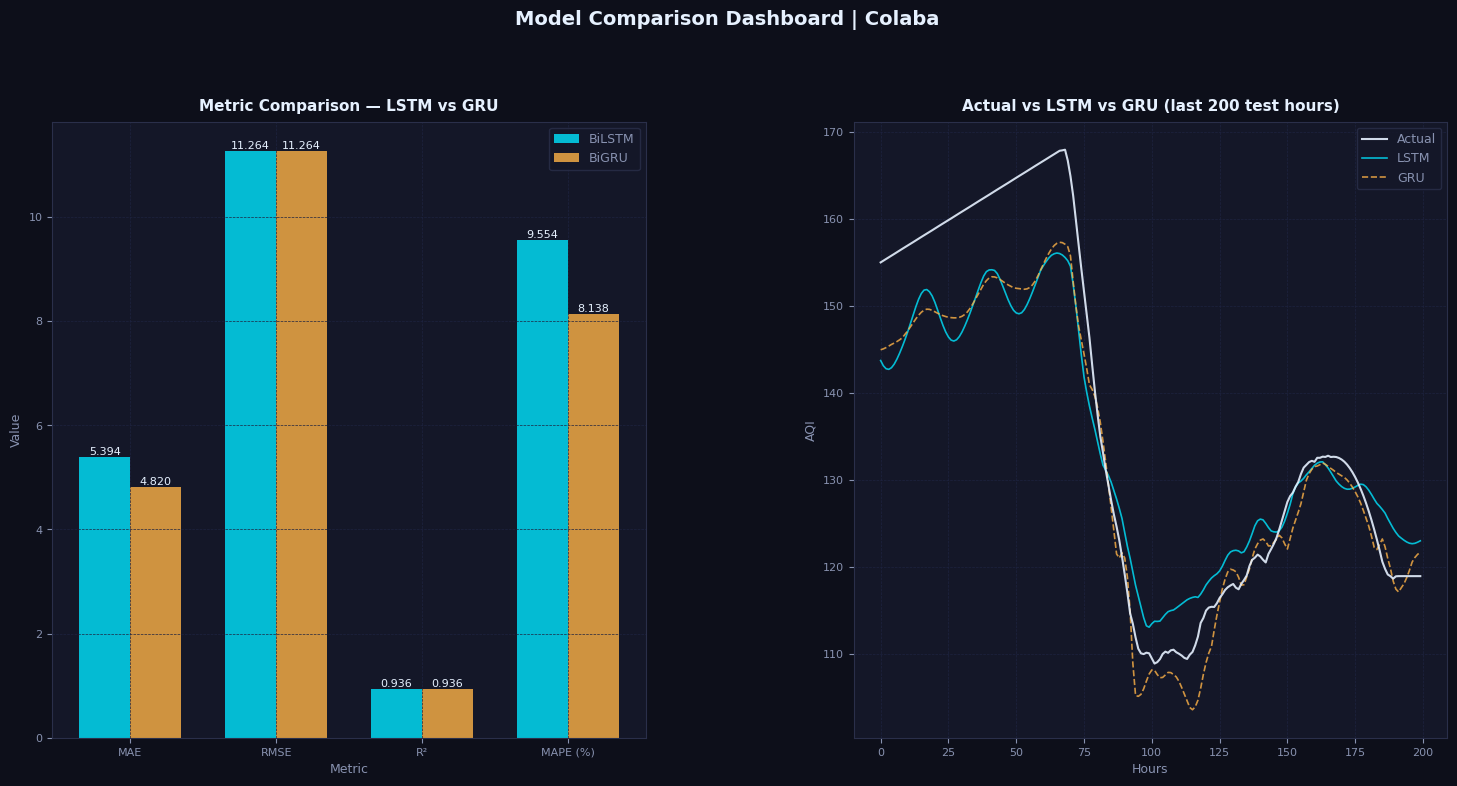

In [25]:
STATION_NAME = 'Colaba'

# ── Radar + bar comparison ───────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8), facecolor=DARK)
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# -- Bar chart: all metrics --------------------------------------------------
ax_bar = fig.add_subplot(gs[0])

metric_names = ['MAE', 'RMSE', 'R²', 'MAPE (%)']
lstm_vals = [metrics_lstm['MAE'], metrics_lstm['RMSE'],
             metrics_lstm['R2'],  metrics_lstm['MAPE']]
gru_vals  = [metrics_gru['MAE'],  metrics_gru['RMSE'],
             metrics_gru['R2'],   metrics_gru['MAPE']]

x = np.arange(len(metric_names))
w = 0.35
b1 = ax_bar.bar(x - w/2, lstm_vals, w, color=ACC1, alpha=0.8, label='BiLSTM')
b2 = ax_bar.bar(x + w/2, gru_vals,  w, color=ACC4, alpha=0.8, label='BiGRU')

for bar in list(b1) + list(b2):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                color=WHITE, fontsize=8)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_names, color=MUTED)
style_ax(ax_bar, 'Metric Comparison — LSTM vs GRU', 'Metric', 'Value')
ax_bar.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

# -- Overlay time-series (last 200 hours of test) ----------------------------
ax_ts = fig.add_subplot(gs[1])
N = 200
ax_ts.plot(y_true_lstm[-N:], color=WHITE,  linewidth=1.5, label='Actual',  alpha=0.9, zorder=3)
ax_ts.plot(y_pred_lstm[-N:], color=ACC1,   linewidth=1.2, label='LSTM',    alpha=0.8, zorder=2)
ax_ts.plot(y_pred_gru[-N:],  color=ACC4,   linewidth=1.2, label='GRU',     alpha=0.8, zorder=2,
           linestyle='--')
style_ax(ax_ts, f'Actual vs LSTM vs GRU (last {N} test hours)', 'Hours', 'AQI')
ax_ts.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

plt.suptitle(f'Model Comparison Dashboard | {STATION_NAME}', color=WHITE, fontsize=14,
             fontweight='bold', y=1.02)
plt.savefig(f'images/model_comparison_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()

## 15. Save Models & Scalers

In [26]:
import joblib

# Save both models
lstm_model.save('saved_models/colaba_lstm_model.keras')
gru_model.save('saved_models/colaba_gru_model.keras')

# Save scalers (required for inference)
joblib.dump(feature_scaler, 'saved_models/colaba_feature_scaler.pkl')
joblib.dump(target_scaler,  'saved_models/colaba_target_scaler.pkl')

print('✅ LSTM model  →  colaba_lstm_model.keras')
print('✅ GRU  model  →  colaba_gru_model.keras')
print('✅ Scalers     →  colaba_feature_scaler.pkl | colaba_target_scaler.pkl')


✅ LSTM model  →  colaba_lstm_model.keras
✅ GRU  model  →  colaba_gru_model.keras
✅ Scalers     →  colaba_feature_scaler.pkl | colaba_target_scaler.pkl


In [27]:
# ── Inference helper ─────────────────────────────────────────────────────────
from tensorflow.keras.models import load_model

def predict_next_aqi(recent_df, model_path, feat_scaler, tgt_scaler,
                     features, look_back=48):
    """
    recent_df  : DataFrame with at least `look_back` rows and all feature columns.
    Returns    : predicted AQI (float) for the next hour.
    """
    model = load_model(model_path)
    scaled = feat_scaler.transform(recent_df[features].tail(look_back))
    x = scaled.reshape(1, look_back, len(features))
    pred_s = model.predict(x, verbose=0)
    return float(tgt_scaler.inverse_transform(pred_s)[0, 0])

# Quick sanity check using the last window from the test set
sample_df = data.iloc[-(LOOK_BACK + 1):-1]   # 48 rows
for mpath, label in [('saved_models/colaba_lstm_model.keras','LSTM'),
                     ('saved_models/colaba_gru_model.keras', 'GRU')]:
    pred = predict_next_aqi(sample_df, mpath,
                            feature_scaler, target_scaler, FEATURES)
    actual = data[TARGET].iloc[-1]
    print(f'{label:5s}  →  Predicted: {pred:.2f}   Actual: {actual:.2f}')

LSTM   →  Predicted: 123.00   Actual: 118.94
GRU    →  Predicted: 121.68   Actual: 118.94


---
## Summary — Colaba AQI LSTM/GRU

| Step | Detail |
|------|--------|
| Dataset | Colaba (Mumbai) — 43,809 hourly records |
| Features | **22 features** — Colaba-specific (no Toluene; Eth-Benzene/MP-Xylene ratio used) |
| Dropped | TOT-RF (all zeros), WD (r ≈ 0), Toluene (not in dataset) |
| Target | AQI (next hour, regression) |
| Scaling | StandardScaler (robust to NO/NOx/NO2 outlier spikes) |
| Look-back window | **48 hours** (ACF = 0.775 at lag 48h) |
| LSTM architecture | BiLSTM(128) → LSTM(64) → BN → Dense(32→16→1) |
| GRU  architecture | BiGRU(128) → GRU(64) → BN → Dense(32→16→1) |
| Optimizer | Adam (lr=0.001) |
| Loss | MSE |
| Train/Val/Test | 70% / 15% / 15% (chronological) |
| Callbacks | EarlyStopping(8), ReduceLROnPlateau(4), ModelCheckpoint |

### Colaba EDA → LSTM Changes vs Original Notebook

| Change | Reason |
|--------|--------|
| Filename: `Colaba_AQI_cleaned.csv` | Dataset is Colaba, not AnandVihar |
| Dropped `TOT-RF` | All 43,809 values are 0 — zero variance |
| Dropped `WD` | Pearson r = 0.005 with AQI — pure noise |
| Removed `Toluene_Benzene_ratio` | Toluene column absent in Colaba |
| Added `EthBenzene_MPXylene_ratio` | Traffic/industrial VOC proxy for Colaba |
| Save files renamed to `colaba_*` | Correct station naming |
| Hourly note added | Colaba AQI is flat (≈93–94/hr) — unlike inland stations |

### Final Feature Tier Table

| Tier | Features | Count |
|------|----------|-------|
| Tier 1 | PM25, PM10, NO2, CO, AQI_lag1, AQI_lag2, AQI_roll3_mean, AQI_roll6_mean | 8 |
| Tier 2 | O3, SO2, NH3, NOx_total, hour_sin, hour_cos, AQI_roll12_mean, PM25_lag1, RH | 9 |
| Tier 3 | NO, WS, AT, SR, EthBenzene_MPXylene_ratio | 5 |
| **Dropped** | TOT-RF, WD, Toluene, Benzene, Eth-Benzene (raw), MP-Xylene (raw), BP, month_sin/cos | — |
